In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import lightgbm as lgb

# Load Data
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
test_ids = test['id']
train.drop(columns='id', inplace=True)
test.drop(columns='id', inplace=True)

# Clean Height
train['Height'] = train['Height'].str.replace('cm', '', regex=False).astype(float)
test['Height'] = test['Height'].str.replace('cm', '', regex=False).astype(float)

# Process Dates
def process_dates(df):
    df['Birth_Date'] = pd.to_datetime(df['Birth_Date'], errors='coerce')
    df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'], errors='coerce')
    df['Surgery_Date'] = pd.to_datetime(df['Surgery_Date'], errors='coerce')
    df['Age'] = df['Diagnosis_Date'].dt.year - df['Birth_Date'].dt.year
    df['Diagnosis_to_Surgery_days'] = (df['Surgery_Date'] - df['Diagnosis_Date']).dt.days
    df.drop(columns=['Birth_Date', 'Diagnosis_Date', 'Surgery_Date'], inplace=True)
    return df

train = process_dates(train)
test = process_dates(test)

# Feature Engineering
# BMI
train['BMI'] = train['Weight'] / ((train['Height'] / 100) ** 2)
test['BMI'] = test['Weight'] / ((test['Height'] / 100) ** 2)

# Age Group
train['Age_Group'] = pd.cut(train['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])
test['Age_Group'] = pd.cut(test['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])

# Tumor Size Binning
train['Tumor_Size_Bin'] = pd.cut(train['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])
test['Tumor_Size_Bin'] = pd.cut(test['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])

# Family History Flag
train['Has_Family_History'] = (train['Family_History'].str.lower() != 'none').astype(int)
test['Has_Family_History'] = (test['Family_History'].str.lower() != 'none').astype(int)

# Multi Treatment Flag
train['Multi_Treatment'] = (
    train['Chemotherapy_Drugs'].notna() &
    (train['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)
test['Multi_Treatment'] = (
    test['Chemotherapy_Drugs'].notna() &
    (test['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)

# Separate label
y_train = train['label']
train.drop(columns='label', inplace=True)

# Impute missing values
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = num_imputer.transform(test[numeric_cols])

train[cat_cols] = train[cat_cols].fillna('Missing')
test[cat_cols] = test[cat_cols].fillna('Missing')

# Convert object columns to categorical dtype before creating lgb.Dataset
for col in cat_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

# Final train/test sets
X_train = train.copy()
X_test = test.copy()

# Split for validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# LightGBM Datasets
lgb_train = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_cols)
lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=cat_cols)

# LightGBM Params
params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

# Train Model
model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=50)
    ]
)

# Validate
val_preds = model.predict(X_val)
val_preds_binary = (val_preds > 0.5).astype(int)

print("Validation Accuracy:", accuracy_score(y_val, val_preds_binary))
print("Classification Report:\n", classification_report(y_val, val_preds_binary))

# Predict on Test Set
test_preds = model.predict(X_test)
test_preds_binary = (test_preds > 0.5).astype(int)

# Submission
submission = pd.DataFrame({
    'id': test_ids,
    'label': test_preds_binary
})
submission.to_csv('submission.csv', index=False)

#Accuracy: 82%

Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_error: 0.183569
Early stopping, best iteration is:
[57]	valid_0's binary_error: 0.182247
Validation Accuracy: 0.817752596789424
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82      2709
           1       0.81      0.82      0.81      2586

    accuracy                           0.82      5295
   macro avg       0.82      0.82      0.82      5295
weighted avg       0.82      0.82      0.82      5295



Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_error: 0.190746
[100]	valid_0's binary_error: 0.191313
Did not meet early stopping. Best iteration is:
[94]	valid_0's binary_error: 0.189046

Best threshold: 0.450 | Best F1 Score: 0.8089
Validation Accuracy: 0.8101983002832861
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2723
           1       0.79      0.83      0.81      2572

    accuracy                           0.81      5295
   macro avg       0.81      0.81      0.81      5295
weighted avg       0.81      0.81      0.81      5295



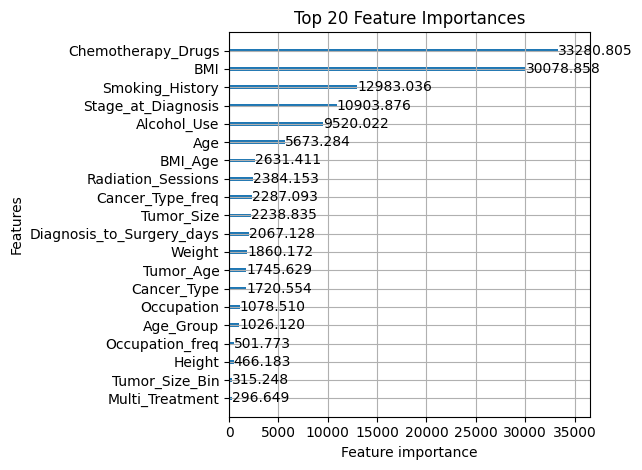

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import matplotlib.pyplot as plt

# Load Data
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
test_ids = test['id']
train.drop(columns='id', inplace=True)
test.drop(columns='id', inplace=True)

# Clean Height
train['Height'] = train['Height'].str.replace('cm', '', regex=False).astype(float)
test['Height'] = test['Height'].str.replace('cm', '', regex=False).astype(float)

# Process Dates
def process_dates(df):
    df['Birth_Date'] = pd.to_datetime(df['Birth_Date'], errors='coerce')
    df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'], errors='coerce')
    df['Surgery_Date'] = pd.to_datetime(df['Surgery_Date'], errors='coerce')
    df['Age'] = df['Diagnosis_Date'].dt.year - df['Birth_Date'].dt.year
    df['Diagnosis_to_Surgery_days'] = (df['Surgery_Date'] - df['Diagnosis_Date']).dt.days
    df.drop(columns=['Birth_Date', 'Diagnosis_Date', 'Surgery_Date'], inplace=True)
    return df

train = process_dates(train)
test = process_dates(test)

# Feature Engineering
train['BMI'] = train['Weight'] / ((train['Height'] / 100) ** 2)
test['BMI'] = test['Weight'] / ((test['Height'] / 100) ** 2)

train['Age_Group'] = pd.cut(train['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])
test['Age_Group'] = pd.cut(test['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])

train['Tumor_Size_Bin'] = pd.cut(train['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])
test['Tumor_Size_Bin'] = pd.cut(test['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])

train['Has_Family_History'] = (train['Family_History'].str.lower() != 'none').astype(int)
test['Has_Family_History'] = (test['Family_History'].str.lower() != 'none').astype(int)

train['Multi_Treatment'] = (
    train['Chemotherapy_Drugs'].notna() &
    (train['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)
test['Multi_Treatment'] = (
    test['Chemotherapy_Drugs'].notna() &
    (test['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)

# ✅ Interaction Features
train['BMI_Age'] = train['BMI'] * train['Age']
test['BMI_Age'] = test['BMI'] * test['Age']

train['Tumor_Age'] = train['Tumor_Size'] * train['Age']
test['Tumor_Age'] = test['Tumor_Size'] * test['Age']

# ✅ Frequency Encoding
for col in ['Occupation', 'Cancer_Type']:
    freq = train[col].value_counts(normalize=True)
    train[col + '_freq'] = train[col].map(freq)
    test[col + '_freq'] = test[col].map(freq).fillna(0)

# Separate label
y_train = train['label']
train.drop(columns='label', inplace=True)

# Impute missing values
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = num_imputer.transform(test[numeric_cols])

train[cat_cols] = train[cat_cols].fillna('Missing')
test[cat_cols] = test[cat_cols].fillna('Missing')

# Convert object columns to categorical dtype
for col in cat_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

# Final train/test sets
X_train = train.copy()
X_test = test.copy()

# Split for validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# LightGBM Datasets
lgb_train = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_cols)
lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=cat_cols)

# LightGBM Params
params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

# Train Model
model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=50)
    ]
)

# Predict validation
val_preds = model.predict(X_val)

# ✅ Threshold Optimization
best_thresh, best_f1 = 0.5, 0
for t in np.linspace(0.3, 0.7, 41):
    preds = (val_preds > t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_thresh, best_f1 = t, f1

val_preds_binary = (val_preds > best_thresh).astype(int)
print(f"\nBest threshold: {best_thresh:.3f} | Best F1 Score: {best_f1:.4f}")
print("Validation Accuracy:", accuracy_score(y_val, val_preds_binary))
print("Classification Report:\n", classification_report(y_val, val_preds_binary))

# Predict on Test Set
test_preds = model.predict(X_test)
test_preds_binary = (test_preds > best_thresh).astype(int)

# Submission
submission = pd.DataFrame({
    'id': test_ids,
    'label': test_preds_binary
})
submission.to_csv('submission.csv', index=False)

# ✅ Feature Importance Plot
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from datetime import datetime

# Load data
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

# Save test IDs
test_ids = test['id']
train.drop(columns='id', inplace=True)
test.drop(columns='id', inplace=True)

# --- Feature Engineering ---

# Height to numeric
train['Height'] = train['Height'].str.replace('cm', '', regex=False).astype(float)
test['Height'] = test['Height'].str.replace('cm', '', regex=False).astype(float)

# Dates → Age and Diagnosis to Surgery days
def process_dates(df):
    df['Birth_Date'] = pd.to_datetime(df['Birth_Date'], errors='coerce')
    df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'], errors='coerce')
    df['Surgery_Date'] = pd.to_datetime(df['Surgery_Date'], errors='coerce')

    df['Age'] = df['Diagnosis_Date'].dt.year - df['Birth_Date'].dt.year
    df['Diagnosis_to_Surgery_days'] = (df['Surgery_Date'] - df['Diagnosis_Date']).dt.days
    df.drop(columns=['Birth_Date', 'Diagnosis_Date', 'Surgery_Date'], inplace=True)
    return df

train = process_dates(train)
test = process_dates(test)

# Calculate BMI
train['BMI'] = train['Weight'] / ((train['Height'] / 100) ** 2)
test['BMI'] = test['Weight'] / ((test['Height'] / 100) ** 2)

# Separate numerical and categorical columns
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numeric_cols.remove('label')  # Exclude label

# --- Missing Values ---
# Impute numeric columns with median
num_imputer = SimpleImputer(strategy='median')
train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = num_imputer.transform(test[numeric_cols])

# Fill categorical with "Missing"
train[categorical_cols] = train[categorical_cols].fillna('Missing')
test[categorical_cols] = test[categorical_cols].fillna('Missing')

# --- Encoding ---
# Combine train + test for encoding
full_data = pd.concat([train.drop(columns='label'), test], axis=0)

# Label Encoding for high-cardinality categorical variables
for col in categorical_cols:
    le = LabelEncoder()
    full_data[col] = le.fit_transform(full_data[col])

# Split back
X_train = full_data.iloc[:len(train), :]
X_test = full_data.iloc[len(train):, :]
y_train = train['label']

# --- Train/Test Split ---
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# --- Model Training (XGBoost) ---
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(xgb, param_grid, cv=3, scoring='accuracy', n_iter=10, random_state=42, n_jobs=-1)
search.fit(X_tr, y_tr)

best_model = search.best_estimator_

# --- Evaluation ---
val_preds = best_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))

# --- Predict on test set ---
test_preds = best_model.predict(X_test)

# --- Submission ---
submission = pd.DataFrame({
    'id': test_ids,
    'label': test_preds
})
submission.to_csv('submission.csv', index=False)

#Accuracy: 80%

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:04:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Validation Accuracy: 0.7969782813975449

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.83      0.81      2709
           1       0.81      0.77      0.79      2586

    accuracy                           0.80      5295
   macro avg       0.80      0.80      0.80      5295
weighted avg       0.80      0.80      0.80      5295



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import lightgbm as lgb

# Load Data
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
test_ids = test['id']
train.drop(columns='id', inplace=True)
test.drop(columns='id', inplace=True)

# Clean Height
train['Height'] = train['Height'].str.replace('cm', '', regex=False).astype(float)
test['Height'] = test['Height'].str.replace('cm', '', regex=False).astype(float)

# Process Dates
def process_dates(df):
    df['Birth_Date'] = pd.to_datetime(df['Birth_Date'], errors='coerce')
    df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'], errors='coerce')
    df['Surgery_Date'] = pd.to_datetime(df['Surgery_Date'], errors='coerce')
    df['Age'] = df['Diagnosis_Date'].dt.year - df['Birth_Date'].dt.year
    df['Diagnosis_to_Surgery_days'] = (df['Surgery_Date'] - df['Diagnosis_Date']).dt.days
    df.drop(columns=['Birth_Date', 'Diagnosis_Date', 'Surgery_Date'], inplace=True)
    return df

train = process_dates(train)
test = process_dates(test)

# Feature Engineering
# BMI
train['BMI'] = train['Weight'] / ((train['Height'] / 100) ** 2)
test['BMI'] = test['Weight'] / ((test['Height'] / 100) ** 2)

# Age Group
train['Age_Group'] = pd.cut(train['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])
test['Age_Group'] = pd.cut(test['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])

# Tumor Size Binning
train['Tumor_Size_Bin'] = pd.cut(train['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])
test['Tumor_Size_Bin'] = pd.cut(test['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])

# Family History Flag
train['Has_Family_History'] = (train['Family_History'].str.lower() != 'none').astype(int)
test['Has_Family_History'] = (test['Family_History'].str.lower() != 'none').astype(int)

# Multi Treatment Flag
train['Multi_Treatment'] = (
    train['Chemotherapy_Drugs'].notna() &
    (train['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)
test['Multi_Treatment'] = (
    test['Chemotherapy_Drugs'].notna() &
    (test['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)

# Separate label
y_train = train['label']
train.drop(columns='label', inplace=True)

# Impute missing values
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = num_imputer.transform(test[numeric_cols])

train[cat_cols] = train[cat_cols].fillna('Missing')
test[cat_cols] = test[cat_cols].fillna('Missing')

# Convert object columns to categorical dtype before creating lgb.Dataset
for col in cat_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

# Final train/test sets
X_train = train.copy()
X_test = test.copy()

# Split for validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# LightGBM Datasets
lgb_train = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_cols)
lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=cat_cols)

# LightGBM Params
params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

# Train Model
model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=50)
    ]
)

# Validate
val_preds = model.predict(X_val)
val_preds_binary = (val_preds > 0.5).astype(int)

print("Validation Accuracy:", accuracy_score(y_val, val_preds_binary))
print("Classification Report:\n", classification_report(y_val, val_preds_binary))

# Predict on Test Set
test_preds = model.predict(X_test)
test_preds_binary = (test_preds > 0.5).astype(int)

# Submission
submission = pd.DataFrame({
    'id': test_ids,
    'label': test_preds_binary
})
submission.to_csv('submission.csv', index=False)

#Accuracy: 82%

Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_error: 0.18678
Early stopping, best iteration is:
[29]	valid_0's binary_error: 0.184136
Validation Accuracy: 0.8158640226628895
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82      2709
           1       0.81      0.81      0.81      2586

    accuracy                           0.82      5295
   macro avg       0.82      0.82      0.82      5295
weighted avg       0.82      0.82      0.82      5295



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import optuna

# Load Data
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
test_ids = test['id']
train.drop(columns='id', inplace=True)
test.drop(columns='id', inplace=True)

# Clean Height
train['Height'] = train['Height'].str.replace('cm', '', regex=False).astype(float)
test['Height'] = test['Height'].str.replace('cm', '', regex=False).astype(float)

# Process Dates
def process_dates(df):
    df['Birth_Date'] = pd.to_datetime(df['Birth_Date'], errors='coerce')
    df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'], errors='coerce')
    df['Surgery_Date'] = pd.to_datetime(df['Surgery_Date'], errors='coerce')
    df['Age'] = df['Diagnosis_Date'].dt.year - df['Birth_Date'].dt.year
    df['Diagnosis_to_Surgery_days'] = (df['Surgery_Date'] - df['Diagnosis_Date']).dt.days
    df.drop(columns=['Birth_Date', 'Diagnosis_Date', 'Surgery_Date'], inplace=True)
    return df

train = process_dates(train)
test = process_dates(test)

# Feature Engineering
train['BMI'] = train['Weight'] / ((train['Height'] / 100) ** 2)
test['BMI'] = test['Weight'] / ((test['Height'] / 100) ** 2)

train['Age_Group'] = pd.cut(train['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])
test['Age_Group'] = pd.cut(test['Age'], bins=[0, 40, 60, 80, 120], labels=['young', 'middle', 'old', 'very_old'])

train['Tumor_Size_Bin'] = pd.cut(train['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])
test['Tumor_Size_Bin'] = pd.cut(test['Tumor_Size'], bins=[0, 2, 5, 10, 20, 100], labels=['tiny', 'small', 'medium', 'large', 'huge'])

train['Has_Family_History'] = (train['Family_History'].str.lower() != 'none').astype(int)
test['Has_Family_History'] = (test['Family_History'].str.lower() != 'none').astype(int)

train['Multi_Treatment'] = (
    train['Chemotherapy_Drugs'].notna() & (train['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)
test['Multi_Treatment'] = (
    test['Chemotherapy_Drugs'].notna() & (test['Radiation_Sessions'].fillna(0).astype(float) > 0)
).astype(int)

# Separate label
y_train = train['label']
train.drop(columns='label', inplace=True)

# Impute missing values
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = num_imputer.transform(test[numeric_cols])

train[cat_cols] = train[cat_cols].fillna('Missing')
test[cat_cols] = test[cat_cols].fillna('Missing')

for col in cat_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

X_train = train.copy()
X_test = test.copy()

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Hyperparameter Tuning with Optuna
def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'binary_error',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 15, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 5.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 5.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'max_bin': trial.suggest_int('max_bin', 100, 255)

    }

    dtrain = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_cols)
    dvalid = lgb.Dataset(X_val, y_val, categorical_feature=cat_cols)

    model = lgb.train(
    param,
    dtrain,
    valid_sets=[dvalid],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
   )


    preds = model.predict(X_val)
    preds_binary = (preds > 0.5).astype(int)
    return 1.0 - accuracy_score(y_val, preds_binary)  # minimize error

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_params = study.best_trial.params
print("Best Params:", best_params)

# Final Model Training with Best Params
final_model = lgb.train(
    {**best_params, 'objective': 'binary', 'metric': 'binary_error', 'verbosity': -1, 'random_state': 42},
    lgb.Dataset(X_train, y_train, categorical_feature=cat_cols),
    num_boost_round=study.best_trial.number + 50  # boost a bit more
)

# Predict on Test Set
test_preds = final_model.predict(X_test)
test_preds_binary = (test_preds > 0.5).astype(int)

# Validate
val_preds = final_model.predict(X_val)
val_preds_binary = (val_preds > 0.5).astype(int)
print("Validation Accuracy:", accuracy_score(y_val, val_preds_binary))
print("Classification Report:\n", classification_report(y_val, val_preds_binary))

# Submission
submission = pd.DataFrame({
    'id': test_ids,
    'label': test_preds_binary
})
submission.to_csv('submission.csv', index=False)

#Best!

[I 2025-05-12 19:23:46,640] A new study created in memory with name: no-name-1e5a0179-79e8-4d0d-af8f-e21934f5de04
[I 2025-05-12 19:23:47,147] Trial 0 finished with value: 0.18583569405099154 and parameters: {'learning_rate': 0.10583725440815635, 'num_leaves': 76, 'max_depth': 10, 'feature_fraction': 0.791106252338097, 'bagging_fraction': 0.6503121340015229, 'bagging_freq': 4, 'min_child_samples': 42, 'lambda_l1': 1.6498501789364557, 'lambda_l2': 2.1913221265603715, 'min_split_gain': 0.2903508114475324, 'max_bin': 226}. Best is trial 0 with value: 0.18583569405099154.
[I 2025-05-12 19:23:47,738] Trial 1 finished with value: 0.1837582625118036 and parameters: {'learning_rate': 0.0546905269864738, 'num_leaves': 40, 'max_depth': 4, 'feature_fraction': 0.9702610917703475, 'bagging_fraction': 0.904593465357533, 'bagging_freq': 1, 'min_child_samples': 72, 'lambda_l1': 3.2373937824638253, 'lambda_l2': 1.330913314232075, 'min_split_gain': 0.8276826189916383, 'max_bin': 186}. Best is trial 1 wit

Best Params: {'learning_rate': 0.03468604375315273, 'num_leaves': 58, 'max_depth': 8, 'feature_fraction': 0.6868868401309949, 'bagging_fraction': 0.7281522474699761, 'bagging_freq': 9, 'min_child_samples': 91, 'lambda_l1': 1.7851281450672003, 'lambda_l2': 1.2121221621895555, 'min_split_gain': 0.447854927172848, 'max_bin': 206}
Validation Accuracy: 0.8302171860245514
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      2709
           1       0.83      0.83      0.83      2586

    accuracy                           0.83      5295
   macro avg       0.83      0.83      0.83      5295
weighted avg       0.83      0.83      0.83      5295

